In [1]:
%matplotlib inline
import numpy as np
import scipy.signal as scipy_sig
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path

BASE_DIR = Path('.')
RAW_DIR = BASE_DIR / 'data' / 'raw'
IR_DIR = BASE_DIR / 'data' / 'ir'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SR = 44100
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


In [2]:
import scipy.signal as sig_regen

def _ensure_data():
    if not (RAW_DIR / 'dry_sine_440.wav').exists():
        print('Data not found, regenerating...')
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        IR_DIR.mkdir(parents=True, exist_ok=True)
        t = np.linspace(0, 2.0, int(SR * 2.0), endpoint=False)
        sine = (0.7 * np.sin(2 * np.pi * 440 * t)).astype(np.float32)
        sf.write(str(RAW_DIR / 'dry_sine_440.wav'), sine, SR, subtype='PCM_16')
        n = int(SR * 2.0)
        arr = np.random.randn(16, n // 16 + 2)
        pink = np.zeros(n)
        for i in range(16):
            chunk = np.repeat(arr[i, :n//16], 16)[:n]
            pink += chunk
        pink = pink / (np.max(np.abs(pink)) + 1e-9) * 0.5
        sf.write(str(RAW_DIR / 'dry_pink_noise.wav'), pink.astype(np.float32), SR, subtype='PCM_16')
        n_ir = int(SR * 0.8)
        t_ir = np.arange(n_ir) / SR
        ir = np.random.randn(n_ir) * np.exp(-5 * t_ir)
        ir[0] = 1.0; ir /= np.max(np.abs(ir))
        sf.write(str(IR_DIR / 'ir_small_room.wav'), ir.astype(np.float32), SR, subtype='PCM_16')
        wet = sig_regen.fftconvolve(sine, ir)[:len(sine)]
        wet /= np.max(np.abs(wet)) + 1e-9
        sf.write(str(RAW_DIR / 'wet_sine_440_small_room.wav'), wet.astype(np.float32), SR, subtype='PCM_16')
        print('Minimal dataset created.')

_ensure_data()

def load_audio(path):
    data, sr = sf.read(str(path), dtype='float32')
    if data.ndim > 1:
        data = data[:, 0]
    return data, sr

dry, _ = load_audio(RAW_DIR / 'dry_sine_440.wav')
wet_path = RAW_DIR / 'wet_sine_440_small_room.wav'
wet, _ = load_audio(wet_path) if wet_path.exists() else (dry.copy(), SR)
pink, _ = load_audio(RAW_DIR / 'dry_pink_noise.wav') if (RAW_DIR / 'dry_pink_noise.wav').exists() else (dry, SR)
print(f'dry: {len(dry)/SR:.2f}s, wet: {len(wet)/SR:.2f}s')

dry: 2.00s, wet: 2.00s


## Plot 1: Waveform with RMS Overlay

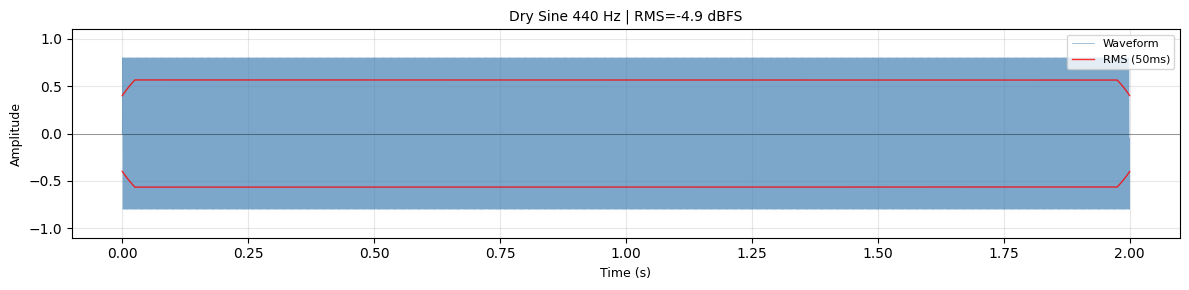

Waveform plot saved.


In [3]:
def plot_waveform(audio, sr, title='Waveform', ax=None, color='steelblue', rms_window_ms=50):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 3))
    t = np.arange(len(audio)) / sr
    ax.plot(t, audio, color=color, linewidth=0.5, alpha=0.7, label='Waveform')
    win = max(1, int(rms_window_ms * 0.001 * sr))
    sq = audio.astype(np.float64) ** 2
    rms = np.sqrt(np.convolve(sq, np.ones(win)/win, mode='same'))
    ax.plot(t, rms, color='red', linewidth=1.0, alpha=0.8, label=f'RMS ({rms_window_ms}ms)')
    ax.plot(t, -rms, color='red', linewidth=1.0, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    rms_db = 20 * np.log10(np.sqrt(np.mean(audio.astype(np.float64)**2)) + 1e-10)
    ax.set_title(f'{title} | RMS={rms_db:.1f} dBFS', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    if standalone:
        plt.tight_layout()
        plt.savefig(PROCESSED_DIR / 'plot_waveform.png', dpi=150, bbox_inches='tight')
        plt.show()

plot_waveform(dry, SR, title='Dry Sine 440 Hz')
print('Waveform plot saved.')

## Plot 2: Spectrogram (STFT)

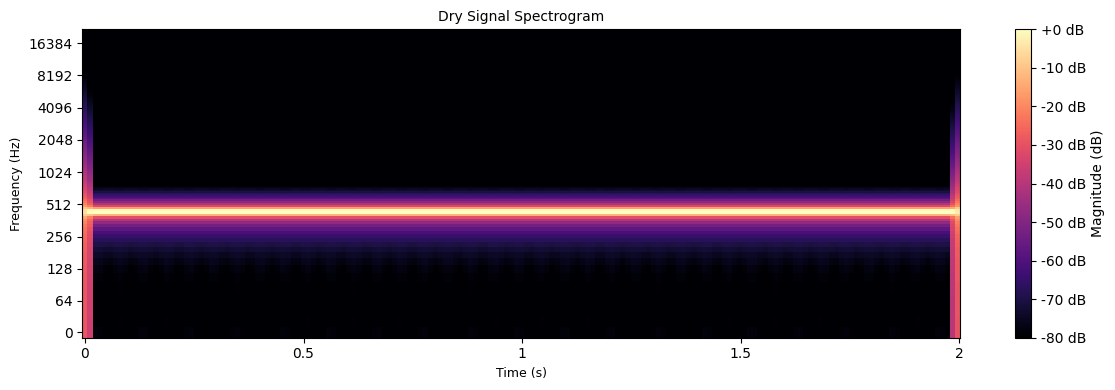

Spectrogram saved.


In [4]:
def plot_spectrogram(audio, sr, title='Spectrogram', ax=None, n_fft=2048, hop_length=512):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 4))
    D = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))
    D_db = librosa.amplitude_to_db(D, ref=np.max)
    img = librosa.display.specshow(D_db, sr=sr, hop_length=hop_length,
                                   x_axis='time', y_axis='log', ax=ax,
                                   cmap='magma', vmin=-80, vmax=0)
    if standalone:
        plt.colorbar(img, ax=ax, format='%+2.0f dB', label='Magnitude (dB)')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('Frequency (Hz)', fontsize=9)
    if standalone:
        plt.tight_layout()
        plt.savefig(PROCESSED_DIR / 'plot_spectrogram.png', dpi=150, bbox_inches='tight')
        plt.show()
    return img

plot_spectrogram(dry, SR, title='Dry Signal Spectrogram')
print('Spectrogram saved.')

## Plot 3: Mel Spectrogram

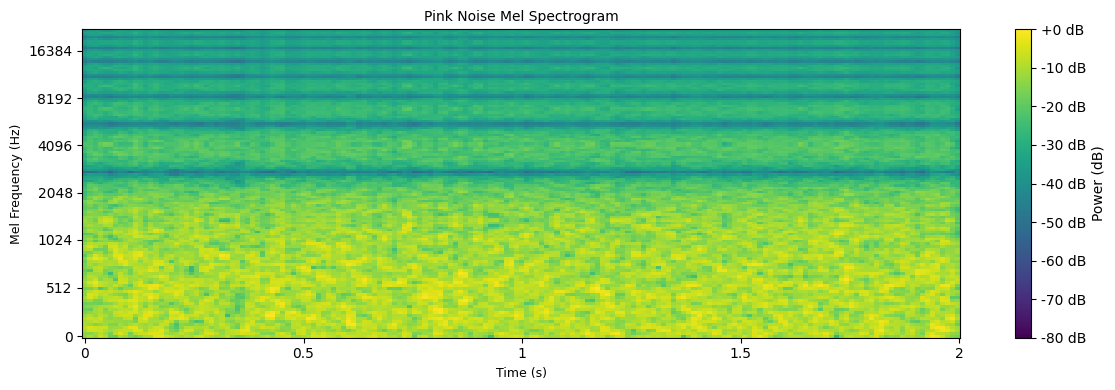

Mel spectrogram saved.


In [5]:
def plot_mel_spectrogram(audio, sr, title='Mel Spectrogram', n_mels=128, n_fft=2048, hop_length=512, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 4))
    M = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    M_db = librosa.power_to_db(M, ref=np.max)
    img = librosa.display.specshow(M_db, sr=sr, hop_length=hop_length,
                                    x_axis='time', y_axis='mel', ax=ax,
                                    cmap='viridis', vmin=-80, vmax=0)
    if standalone:
        plt.colorbar(img, ax=ax, format='%+2.0f dB', label='Power (dB)')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('Mel Frequency (Hz)', fontsize=9)
    if standalone:
        plt.tight_layout()
        plt.savefig(PROCESSED_DIR / 'plot_mel_spectrogram.png', dpi=150, bbox_inches='tight')
        plt.show()
    return img

plot_mel_spectrogram(pink, SR, title='Pink Noise Mel Spectrogram')
print('Mel spectrogram saved.')

## Plots 4 & 5: Frequency and Phase Response

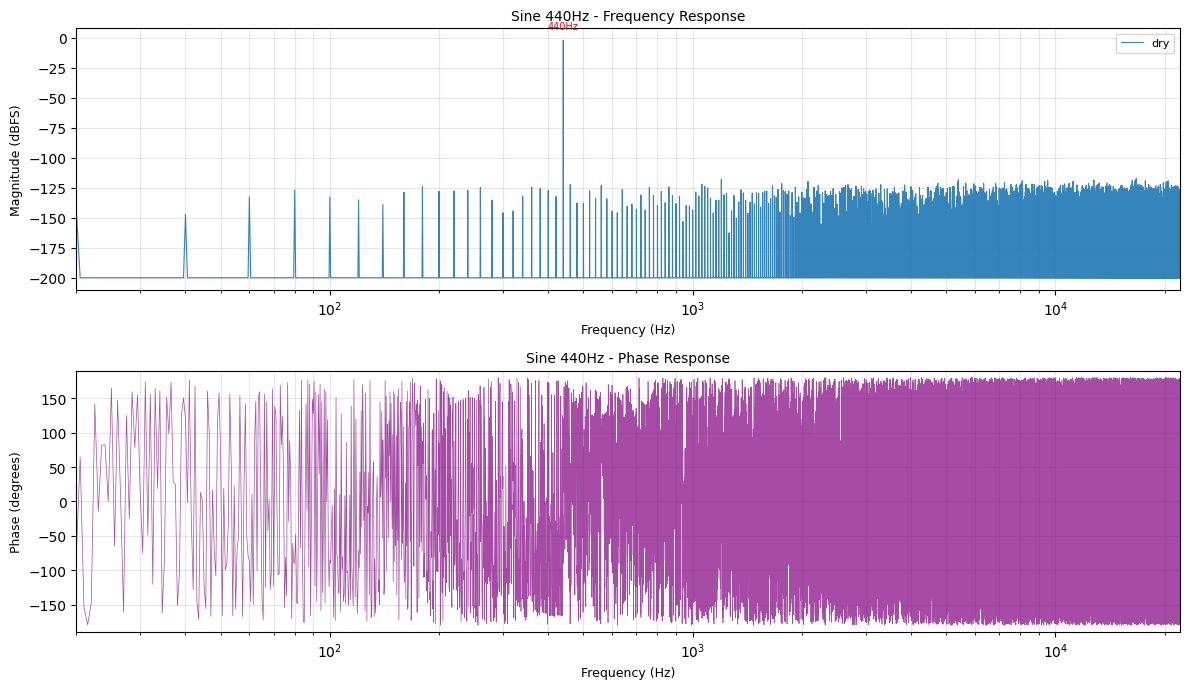

Frequency and phase response saved.


In [6]:
def plot_frequency_response(audio, sr, title='Frequency Response', ax=None, label='signal'):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 4))
    N = len(audio)
    freqs = np.fft.rfftfreq(N, 1/sr)
    spectrum = np.fft.rfft(audio)
    mag_db = 20 * np.log10(np.abs(spectrum) / (N/2) + 1e-10)
    ax.semilogx(freqs[1:], mag_db[1:], linewidth=0.8, label=label, alpha=0.9)
    peaks, _ = scipy_sig.find_peaks(mag_db[1:], height=-60, distance=int(sr/100))
    for pk in peaks[:5]:
        f = freqs[1:][pk]
        ax.annotate(f'{f:.0f}Hz', xy=(f, mag_db[1:][pk]),
                    xytext=(0, 8), textcoords='offset points', fontsize=7, ha='center', color='red')
    ax.set_xlim(20, sr/2)
    ax.set_xlabel('Frequency (Hz)', fontsize=9); ax.set_ylabel('Magnitude (dBFS)', fontsize=9)
    ax.set_title(title, fontsize=10); ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=8)
    if standalone:
        plt.tight_layout()
        plt.savefig(PROCESSED_DIR / 'plot_frequency_response.png', dpi=150, bbox_inches='tight')
        plt.show()

def plot_phase_response(audio, sr, title='Phase Response', ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 4))
    N = len(audio)
    freqs = np.fft.rfftfreq(N, 1/sr)
    spectrum = np.fft.rfft(audio)
    phase = np.angle(spectrum, deg=True)
    ax.semilogx(freqs[1:], phase[1:], linewidth=0.5, color='purple', alpha=0.7)
    ax.set_xlim(20, sr/2)
    ax.set_xlabel('Frequency (Hz)', fontsize=9); ax.set_ylabel('Phase (degrees)', fontsize=9)
    ax.set_title(title, fontsize=10); ax.grid(True, alpha=0.3, which='both'); ax.set_ylim(-190, 190)
    if standalone:
        plt.tight_layout()
        plt.savefig(PROCESSED_DIR / 'plot_phase_response.png', dpi=150, bbox_inches='tight')
        plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_frequency_response(dry, SR, 'Sine 440Hz - Frequency Response', ax=axes[0], label='dry')
plot_phase_response(dry, SR, 'Sine 440Hz - Phase Response', ax=axes[1])
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'plot_freq_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Frequency and phase response saved.')

## Plot 6 & 7: Impulse Response and RT60 Estimation

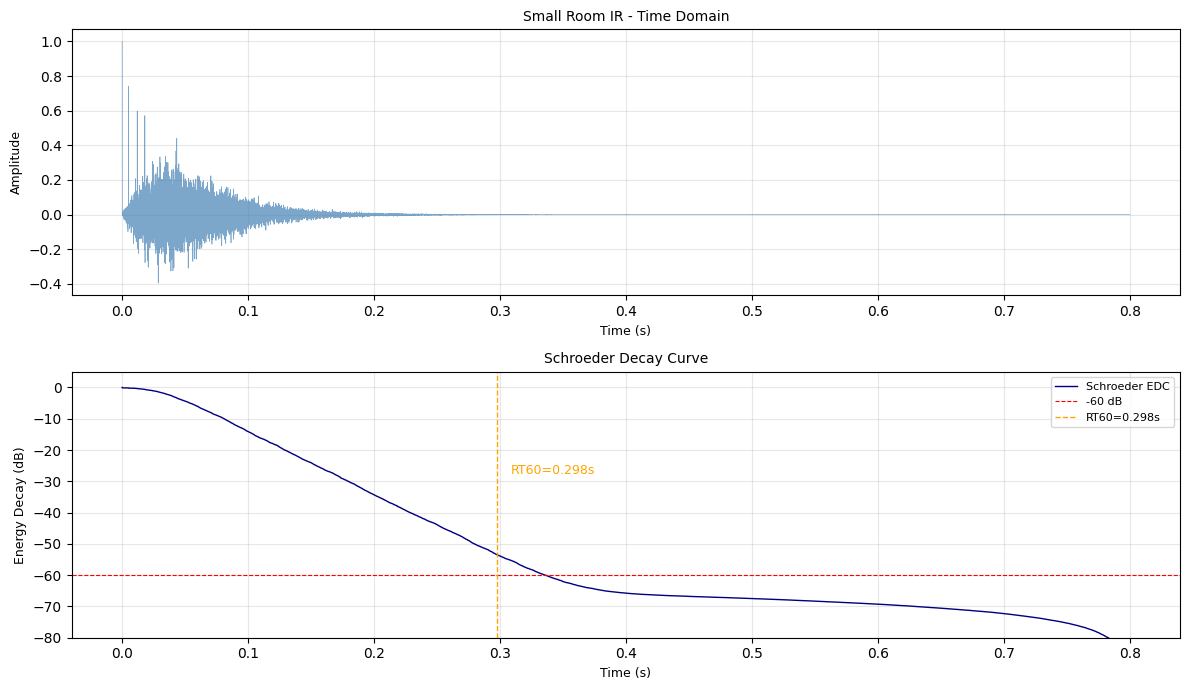

RT60 = 0.298s


In [7]:
def schroeder_decay_curve(ir):
    energy = ir.astype(np.float64) ** 2
    edc = np.cumsum(energy[::-1])[::-1]
    edc_db = 10 * np.log10(edc / (edc[0] + 1e-20) + 1e-20)
    return edc_db

def estimate_rt60(ir, sr):
    edc_db = schroeder_decay_curve(ir)
    t = np.arange(len(ir)) / sr
    idx_5  = np.argmax(edc_db <= -5)
    idx_35 = np.argmax(edc_db <= -35)
    if idx_5 == 0 or idx_35 == 0 or idx_35 <= idx_5:
        return None, edc_db
    t_region = t[idx_5:idx_35]
    edc_region = edc_db[idx_5:idx_35]
    coeffs = np.polyfit(t_region, edc_region, 1)
    rt60 = -60 / coeffs[0] if coeffs[0] != 0 else None
    return rt60, edc_db

def plot_impulse_response(ir, sr, title='Impulse Response', save_path=None):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    t = np.arange(len(ir)) / sr
    axes[0].plot(t, ir, linewidth=0.5, color='steelblue', alpha=0.7)
    axes[0].set_title(f'{title} - Time Domain', fontsize=10)
    axes[0].set_xlabel('Time (s)', fontsize=9); axes[0].set_ylabel('Amplitude', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    rt60, edc_db = estimate_rt60(ir, sr)
    axes[1].plot(t, edc_db, color='navy', linewidth=1.0, label='Schroeder EDC')
    axes[1].axhline(-60, color='red', linestyle='--', linewidth=0.8, label='-60 dB')
    if rt60 is not None and 0 < rt60 < len(ir)/sr:
        axes[1].axvline(rt60, color='orange', linestyle='--', linewidth=1.0, label=f'RT60={rt60:.3f}s')
        axes[1].annotate(f'RT60={rt60:.3f}s', xy=(rt60, -30),
                         xytext=(10, 5), textcoords='offset points', fontsize=9, color='orange')
    axes[1].set_ylim(-80, 5)
    axes[1].set_xlabel('Time (s)', fontsize=9); axes[1].set_ylabel('Energy Decay (dB)', fontsize=9)
    axes[1].set_title('Schroeder Decay Curve', fontsize=10)
    axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return rt60

ir_path = IR_DIR / 'ir_small_room.wav'
if ir_path.exists():
    ir, _ = load_audio(ir_path)
else:
    n_ir = int(SR * 0.8); t_ir = np.arange(n_ir)/SR
    ir = (np.random.randn(n_ir) * np.exp(-5*t_ir)).astype(np.float32)
    ir[0] = 1.0; ir /= np.max(np.abs(ir))

rt60 = plot_impulse_response(ir, SR, 'Small Room IR', save_path=PROCESSED_DIR / 'plot_ir_rt60.png')
print(f'RT60 = {rt60:.3f}s' if rt60 else 'RT60 estimation not available')

## RT60 Per Octave Band

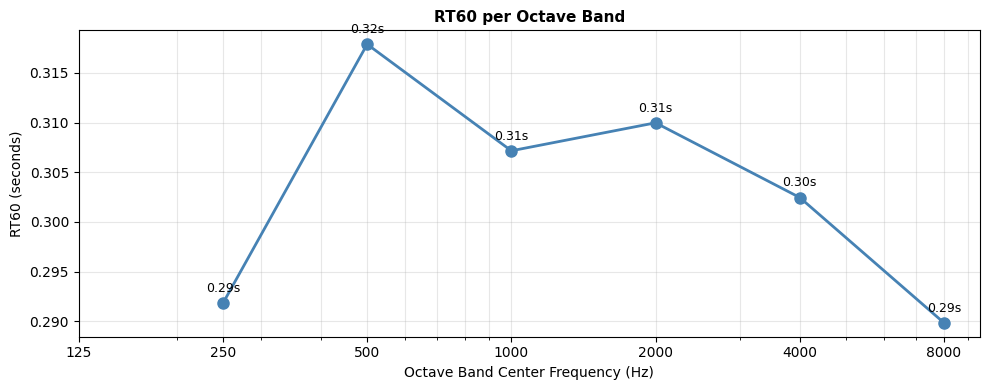

RT60 bands: {125: None, 250: np.float64(0.292), 500: np.float64(0.318), 1000: np.float64(0.307), 2000: np.float64(0.31), 4000: np.float64(0.302), 8000: np.float64(0.29)}


In [8]:
def rt60_per_octave_band(ir, sr):
    center_freqs = [125, 250, 500, 1000, 2000, 4000, 8000]
    rt60s = []
    for fc in center_freqs:
        f_low = max(1.0, fc / np.sqrt(2))
        f_high = min(sr * 0.45, fc * np.sqrt(2))
        if f_low >= f_high or f_high > sr/2:
            rt60s.append(np.nan); continue
        b, a = scipy_sig.butter(4, [f_low/(sr/2), f_high/(sr/2)], btype='band')
        ir_band = scipy_sig.lfilter(b, a, ir.astype(np.float64))
        rt60_val, _ = estimate_rt60(ir_band, sr)
        rt60s.append(rt60_val if rt60_val is not None else np.nan)
    return center_freqs, rt60s

center_freqs, rt60s = rt60_per_octave_band(ir, SR)
valid = [(f, r) for f, r in zip(center_freqs, rt60s) if r and not np.isnan(r) and 0 < r < 10]

fig, ax = plt.subplots(figsize=(10, 4))
if valid:
    fs_v, rs_v = zip(*valid)
    ax.semilogx(fs_v, rs_v, 'o-', color='steelblue', linewidth=2, markersize=8)
    for f, r in valid:
        ax.annotate(f'{r:.2f}s', xy=(f, r), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
ax.set_xlabel('Octave Band Center Frequency (Hz)', fontsize=10)
ax.set_ylabel('RT60 (seconds)', fontsize=10)
ax.set_title('RT60 per Octave Band', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.set_xticks([125, 250, 500, 1000, 2000, 4000, 8000])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'plot_rt60_bands.png', dpi=150, bbox_inches='tight')
plt.show()
print('RT60 bands:', dict(zip(center_freqs, [round(r, 3) if r and not np.isnan(r) else None for r in rt60s])))

## Plot 8: Cepstrum for Echo Detection

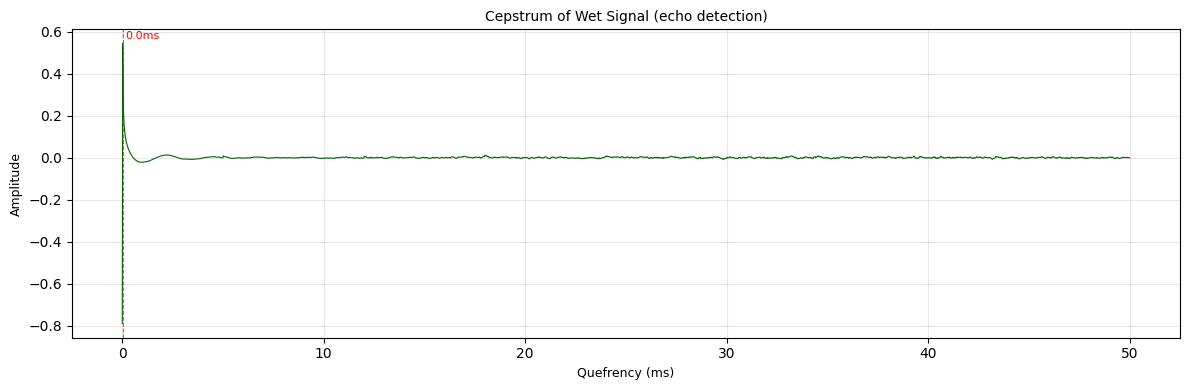

Cepstrum plot saved.


In [9]:
def plot_cepstrum(audio, sr, title='Cepstrum', max_quefrency_ms=50, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 4))
    N = len(audio)
    spectrum = np.fft.rfft(audio.astype(np.float64), n=N)
    log_mag = np.log(np.abs(spectrum) + 1e-10)
    cepstrum = np.fft.irfft(log_mag)
    quefrency = np.arange(len(cepstrum)) / sr * 1000
    q_mask = quefrency <= max_quefrency_ms
    ax.plot(quefrency[q_mask], cepstrum[q_mask], color='darkgreen', linewidth=0.8)
    peaks, _ = scipy_sig.find_peaks(cepstrum[q_mask],
                                     height=np.std(cepstrum[q_mask]) * 2,
                                     distance=max(1, int(sr * 0.001)))
    for pk in peaks[:3]:
        q = quefrency[q_mask][pk]
        ax.axvline(q, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.annotate(f'{q:.1f}ms', xy=(q, cepstrum[q_mask][pk]),
                    xytext=(2, 3), textcoords='offset points', fontsize=8, color='red')
    ax.set_xlabel('Quefrency (ms)', fontsize=9); ax.set_ylabel('Amplitude', fontsize=9)
    ax.set_title(title, fontsize=10); ax.grid(True, alpha=0.3)
    if standalone:
        plt.tight_layout()
        plt.savefig(PROCESSED_DIR / 'plot_cepstrum.png', dpi=150, bbox_inches='tight')
        plt.show()

plot_cepstrum(wet, SR, title='Cepstrum of Wet Signal (echo detection)')
print('Cepstrum plot saved.')

## Plot 9: Dry vs Wet Side-by-Side

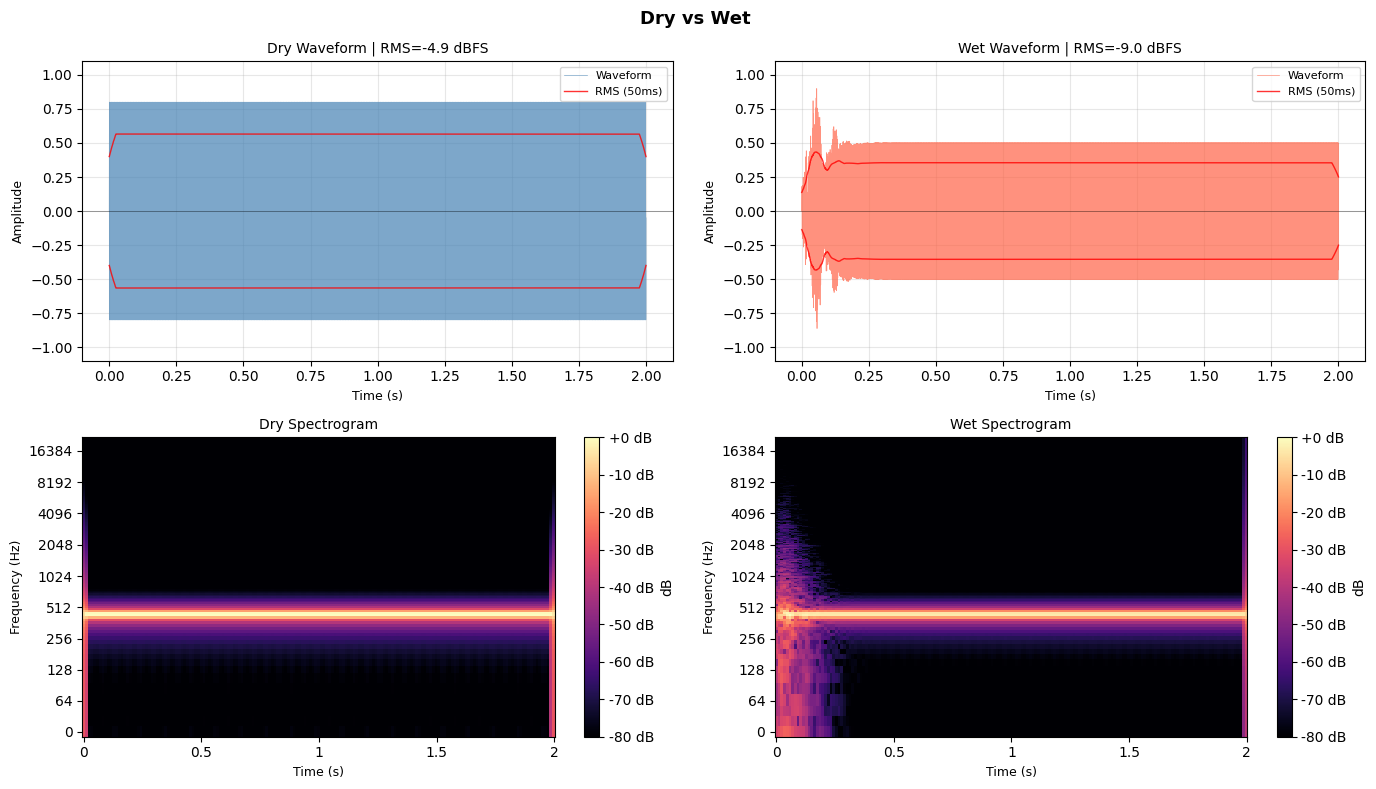

Dry/wet comparison saved.


In [10]:
def plot_dry_wet_comparison(dry_sig, wet_sig, sr, title='Dry vs Wet'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    plot_waveform(dry_sig, sr, title='Dry Waveform', ax=axes[0, 0], color='steelblue')
    plot_waveform(wet_sig, sr, title='Wet Waveform', ax=axes[0, 1], color='tomato')
    img1 = plot_spectrogram(dry_sig, sr, title='Dry Spectrogram', ax=axes[1, 0])
    img2 = plot_spectrogram(wet_sig, sr, title='Wet Spectrogram', ax=axes[1, 1])
    plt.colorbar(img1, ax=axes[1, 0], format='%+2.0f dB', label='dB')
    plt.colorbar(img2, ax=axes[1, 1], format='%+2.0f dB', label='dB')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / 'plot_dry_wet_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_dry_wet_comparison(dry, wet, SR)
print('Dry/wet comparison saved.')

## Plot 10: SchroederReverb Room Size Sweep

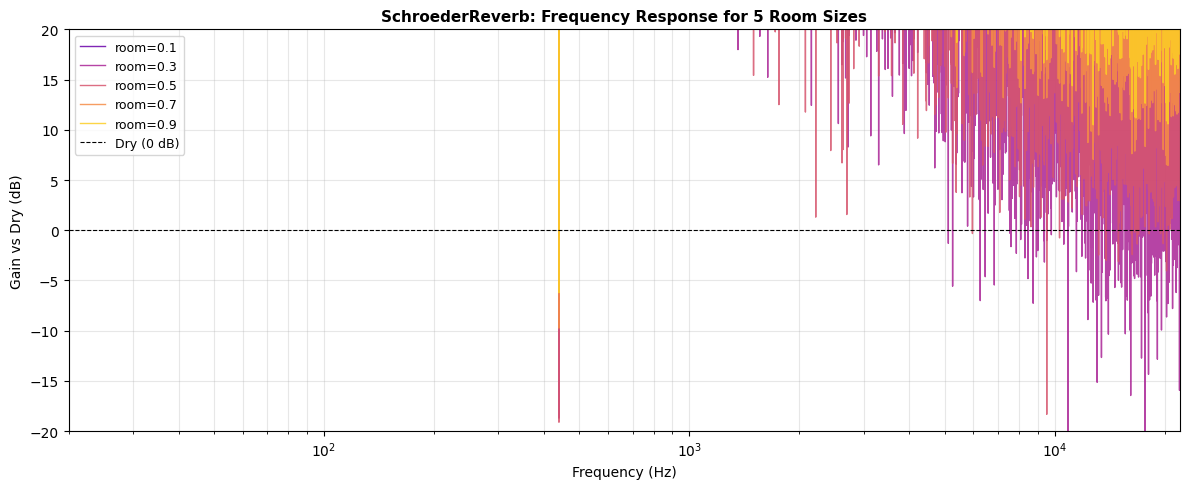

Room size sweep saved.


In [11]:
def schroeder_simple(dry_in, sr, room_size=0.5, damping=0.4, wet_mix=0.5):
    scale = 0.5 + room_size * 0.5
    comb_delays = [int(d * scale * sr / 1000) for d in [29.7, 37.1, 41.1, 43.7]]
    feedback = 0.7 + room_size * 0.18
    damp_v = damping * 0.4
    def comb_f(x, d, fb, dp):
        d = max(1, int(d)); buf = np.zeros(d); y = np.zeros(len(x)); fs = 0.0; pos = 0
        for i in range(len(x)):
            ov = buf[pos]; fs = ov*(1-dp) + fs*dp
            buf[pos] = x[i] + fs*fb; y[i] = ov; pos = (pos+1) % d
        return y
    def ap_f(x, d, g=0.5):
        d = max(1, int(d)); buf = np.zeros(d); y = np.zeros(len(x)); pos = 0
        for i in range(len(x)):
            b = buf[pos]; buf[pos] = x[i]+b*g; y[i] = b-x[i]*g; pos = (pos+1)%d
        return y
    co = np.zeros(len(dry_in))
    for cd in comb_delays:
        co += comb_f(dry_in, cd, feedback, damp_v)
    co *= 0.25
    for ad in [int(5.0*sr/1000), int(1.7*sr/1000)]:
        co = ap_f(co, ad)
    return np.clip((1-wet_mix)*dry_in + wet_mix*co, -1, 1).astype(np.float32)

room_sizes = [0.1, 0.3, 0.5, 0.7, 0.9]
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(room_sizes)))
fig, ax = plt.subplots(figsize=(12, 5))
N = len(dry)
freqs = np.fft.rfftfreq(N, 1/SR)
dry_mag = 20 * np.log10(np.abs(np.fft.rfft(dry)) + 1e-10)
for rs, col in zip(room_sizes, colors):
    w = schroeder_simple(dry, SR, room_size=rs, wet_mix=0.6)
    wet_mag = 20 * np.log10(np.abs(np.fft.rfft(w)) + 1e-10)
    ax.semilogx(freqs[1:], wet_mag[1:] - dry_mag[1:], linewidth=1.0,
                color=col, label=f'room={rs:.1f}', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Dry (0 dB)')
ax.set_xlim(20, SR/2); ax.set_ylim(-20, 20)
ax.set_xlabel('Frequency (Hz)', fontsize=10); ax.set_ylabel('Gain vs Dry (dB)', fontsize=10)
ax.set_title('SchroederReverb: Frequency Response for 5 Room Sizes', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'plot_reverb_room_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Room size sweep saved.')

In [12]:
saved_plots = list(PROCESSED_DIR.glob('plot_*.png'))
print('=' * 50)
print('NOTEBOOK 02 COMPLETE')
print('=' * 50)
print(f'Plots saved ({len(saved_plots)}):')
for p in sorted(saved_plots):
    print(f'  {p.name}')
print('\nCheckmark: Notebook complete')

NOTEBOOK 02 COMPLETE
Plots saved (9):
  plot_cepstrum.png
  plot_dry_wet_comparison.png
  plot_freq_phase.png
  plot_ir_rt60.png
  plot_mel_spectrogram.png
  plot_reverb_room_sweep.png
  plot_rt60_bands.png
  plot_spectrogram.png
  plot_waveform.png

Checkmark: Notebook complete
